In [8]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [9]:
import os
print(os.listdir('AngularPS/processed_tensors/modelB'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [10]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [11]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/modelB/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/modelB/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/modelB/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 14400, 'valid': 1800, 'test': 1800}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

torch.Size([14400, 1, 20, 40])
torch.Size([14400, 1])
训练集: 14400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 1800 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1800 样本, 数据形状 torch.Size([1, 20, 40])


定义CNN模型

In [14]:
import torch
import torch.nn as nn

class CNN_SingleParam(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNN_SingleParam, self).__init__()
        
        # 输入形状: (batch, 1, 20, 40)
        
        # 第一块卷积
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # -> (32, 20, 40)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)                             # -> (32, 10, 20)
        
        # 第二块卷积
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> (64, 10, 20)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)                             # -> (64, 5, 10)
        
        # 展平
        self.flatten = nn.Flatten()
        
        # 全连接层
        # 特征维度：64 channels * 5 height * 10 width = 3200
        self.fc1     = nn.Linear(64 * 5 * 10, 256)
        self.relu3   = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # 输出层：单参数回归，只输出 1 个值
        self.fc_out  = nn.Linear(256, 1)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc_out(x)          # 形状: (batch_size, 1)
        
        return x.squeeze(1)         # 返回 (batch_size,) 的一维张量，便于计算 MSELoss

定义训练函数

In [20]:
import pandas as pd
from torch.optim.lr_scheduler import ReduceLROnPlateau

def r2_score(y_true, y_pred):
    """
    计算 R² 分数（标量标签版本）
    y_true, y_pred: Tensor of shape (N,)
    """
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_model(model, train_loader, valid_loader, epochs=200, patience=30, lr=0.001, 
                save_csv_path='training_history_modelB.csv'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    
    criterion = nn.MSELoss()
    mae_metric = MeanAbsoluteError().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-6)
    
    best_valid_loss = float('inf')
    early_stop_counter = 0
    
    # 用于记录每个 epoch 的指标
    history = {
        'epoch': [],
        'train_loss': [],
        'train_mae': [],
        'valid_loss': [],
        'valid_mae': [],
        'valid_r2': []
    }

    for epoch in range(epochs):
        # ------------------- Training -------------------
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        train_samples = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            if y.dim() == 2:
                y = y.squeeze(1)
                
            optimizer.zero_grad()
            output = model(x)
            
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            train_mae += mae_metric(output, y).item() * batch_size
            train_samples += batch_size
        
        train_loss /= train_samples
        train_mae /= train_samples

        # ------------------- Validation -------------------
        model.eval()
        valid_loss = 0.0
        valid_mae = 0.0
        valid_samples = 0
        all_preds = []
        all_trues = []
        
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                if y.dim() == 2:
                    y = y.squeeze(1)
                    
                output = model(x)
                
                loss = criterion(output, y)
                
                batch_size = x.size(0)
                valid_loss += loss.item() * batch_size
                valid_mae += mae_metric(output, y).item() * batch_size
                valid_samples += batch_size
                
                all_preds.append(output.cpu())
                all_trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae /= valid_samples
        
        all_pred = torch.cat(all_preds)
        all_true = torch.cat(all_trues)
        valid_r2 = r2_score(all_true, all_pred).item()

        # ------------------- Record History -------------------
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['train_mae'].append(train_mae)
        history['valid_loss'].append(valid_loss)
        history['valid_mae'].append(valid_mae)
        history['valid_r2'].append(valid_r2)

        print(f'Epoch {epoch+1:3d}/{epochs} | '
              f'Train Loss: {train_loss:.6f} | Train MAE: {train_mae:.4f} | '
              f'Valid Loss: {valid_loss:.6f} | Valid MAE: {valid_mae:.4f} | '
              f'Valid R²: {valid_r2:.4f}')

        # ------------------- Early Stopping & Save Best -------------------
        scheduler.step(valid_loss)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model_pre.pt')
            early_stop_counter = 0
            print("  → New best model saved!")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # ------------------- Save Training History to CSV -------------------
    if save_csv_path:
        df = pd.DataFrame(history)
        # 确保目录存在
        os.makedirs(os.path.dirname(save_csv_path) if os.path.dirname(save_csv_path) else '.', exist_ok=True)
        df.to_csv(save_csv_path, index=False)
        print(f"\nTraining history saved to: {save_csv_path}")

    # 加载最佳模型
    print("Loading best model weights...")
    model.load_state_dict(torch.load('best_model_pre.pt'))
    
    return model, history  # 返回模型和历史记录，方便后续绘图

定义测试函数

In [12]:
import torch
import torch.nn as nn
from torchmetrics import MeanAbsoluteError  # 如果你用了 torchmetrics

def r2_score(y_true, y_pred):
    """
    计算 R² 分数（单参数版本）
    y_true, y_pred: Tensor of shape (N,)
    """
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def test_model(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    criterion = nn.MSELoss()
    mae_metric = MeanAbsoluteError().to(device)
    
    test_loss = 0.0
    test_mae = 0.0
    test_samples = 0
    
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            
            # 如果标签是 (B, 1)，squeeze 成 (B,)
            if y.dim() == 2:
                y = y.squeeze(1)
                
            output = model(x)  # output: (B,)  —— 因为模型里已经 squeeze 了
            
            loss = criterion(output, y)
            
            batch_size = x.size(0)
            test_loss += loss.item() * batch_size
            test_mae += mae_metric(output, y).item() * batch_size
            test_samples += batch_size
            
            # 收集预测和真实值（用于 R² 计算）
            all_preds.append(output.cpu())
            all_trues.append(y.cpu())
    
    # 计算平均指标
    test_loss /= test_samples
    test_mae /= test_samples
    
    # 计算整体 R²
    all_pred = torch.cat(all_preds)
    all_true = torch.cat(all_trues)
    test_r2 = r2_score(all_true, all_pred).item()
    
    # 转为 numpy（方便后续绘图或保存）
    predictions = all_pred.numpy()   # shape: (N,)
    trues = all_true.numpy()         # shape: (N,)

    print(f'Test Loss: {test_loss:.6f} | '
          f'Test MAE: {test_mae:.4f} | '
          f'Test R²: {test_r2:.4f}')

    return test_loss, test_mae, test_r2, predictions, trues

主程序：加载数据、训练和测试

In [22]:
import torch
import numpy as np

# ------------------- 1. 加载数据 -------------------
# 假设你已经定义了 load_data() 函数，返回三个 DataLoader
# train_loader: 训练集
# valid_loader: 验证集
# test_loader:  测试集
train_loader, valid_loader, test_loader = load_data()

print(f"数据加载完成："
      f"Train {len(train_loader.dataset)} | "
      f"Valid {len(valid_loader.dataset)} | "
      f"Test {len(test_loader.dataset)}")

# ------------------- 2. 初始化模型 -------------------
model = CNN_SingleParam(dropout_rate=0.3)  # 使用我们之前定义的单参数模型

# ------------------- 3. 训练模型 -------------------
model, history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=500,        # 单参数任务通常收敛更快，可适当增加
    patience=80,
    lr=0.003,
    save_csv_path='logs/modelB_training_history.csv'
)

# 注意：train_model 内部已经自动保存并加载了最佳模型（best_model_pre.pt）
# 所以这里不需要再手动 load

# ------------------- 4. 测试模型 -------------------
test_loss, test_mae, test_r2, predictions, trues = test_model(model, test_loader)

# predictions 和 trues 当前是归一化后的值（numpy array, shape: (N,)）

# ------------------- 5. 反归一化到原始 klw 尺度 -------------------
label_stats = torch.load('AngularPS/processed_tensors/modelB/label_stats.pt')
mean = label_stats['mean'].item()   # 标量
std = label_stats['std'].item()     # 标量

# 反归一化
predictions_original = predictions * std + mean
trues_original = trues * std + mean

# 计算原始尺度下的 MAE
mae_original = np.mean(np.abs(predictions_original - trues_original))

print("\n" + "="*60)
print("测试集最终结果（原始 klw 尺度）")
print("="*60)
print(f"Test Loss (归一化): {test_loss:.6f}")
print(f"Test MAE  (归一化): {test_mae:.4f}")
print(f"Test R²   (归一化): {test_r2:.4f}")
print(f"Test MAE  (原始 klw): {mae_original:.4f}")
print("="*60)

# ------------------- 6. 打印前几个样本的预测与真实值 -------------------
print("\n前 10 个测试样本预测 vs 真实值（klw）：")
print("样本\t预测值\t\t真实值\t\t误差")
print("-" * 50)
n_show = min(10, len(predictions_original))
for i in range(n_show):
    pred = predictions_original[i]
    true = trues_original[i]
    error = pred - true
    print(f"{i+1:2d}\t{pred:.4f}\t\t{true:.4f}\t\t{error:+.4f}")

print("\n测试完成！")

torch.Size([14400, 1, 20, 40])
torch.Size([14400, 1])
训练集: 14400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 1800 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1800 样本, 数据形状 torch.Size([1, 20, 40])
数据加载完成：Train 14400 | Valid 1800 | Test 1800
Using device: cuda
Epoch   1/500 | Train Loss: 0.789409 | Train MAE: 0.4213 | Valid Loss: 0.142315 | Valid MAE: 0.3213 | Valid R²: 0.8628
  → New best model saved!
Epoch   2/500 | Train Loss: 0.115254 | Train MAE: 0.2529 | Valid Loss: 0.127020 | Valid MAE: 0.3031 | Valid R²: 0.8775
  → New best model saved!
Epoch   3/500 | Train Loss: 0.096768 | Train MAE: 0.2309 | Valid Loss: 0.138113 | Valid MAE: 0.3219 | Valid R²: 0.8669
Epoch   4/500 | Train Loss: 0.094589 | Train MAE: 0.2262 | Valid Loss: 0.114211 | Valid MAE: 0.2782 | Valid R²: 0.8899
  → New best model saved!
Epoch   5/500 | Train Loss: 0.080268 | Train MAE: 0.2056 | Valid Loss: 0.056985 | Valid MAE: 0.1934 | Valid R²: 0.9451
  → New best model saved!
Epoch   6/500 | Train Loss: 0.093668 | Train MAE: 0.22

测试集参数估计可视化

训练历史前几行：
   epoch  train_loss  train_mae  valid_loss  valid_mae  valid_r2
0      1    0.789409   0.421349    0.142315   0.321319  0.862804
1      2    0.115254   0.252858    0.127020   0.303092  0.877548
2      3    0.096768   0.230917    0.138113   0.321901  0.866854
3      4    0.094589   0.226155    0.114211   0.278191  0.889896
4      5    0.080268   0.205620    0.056985   0.193397  0.945065


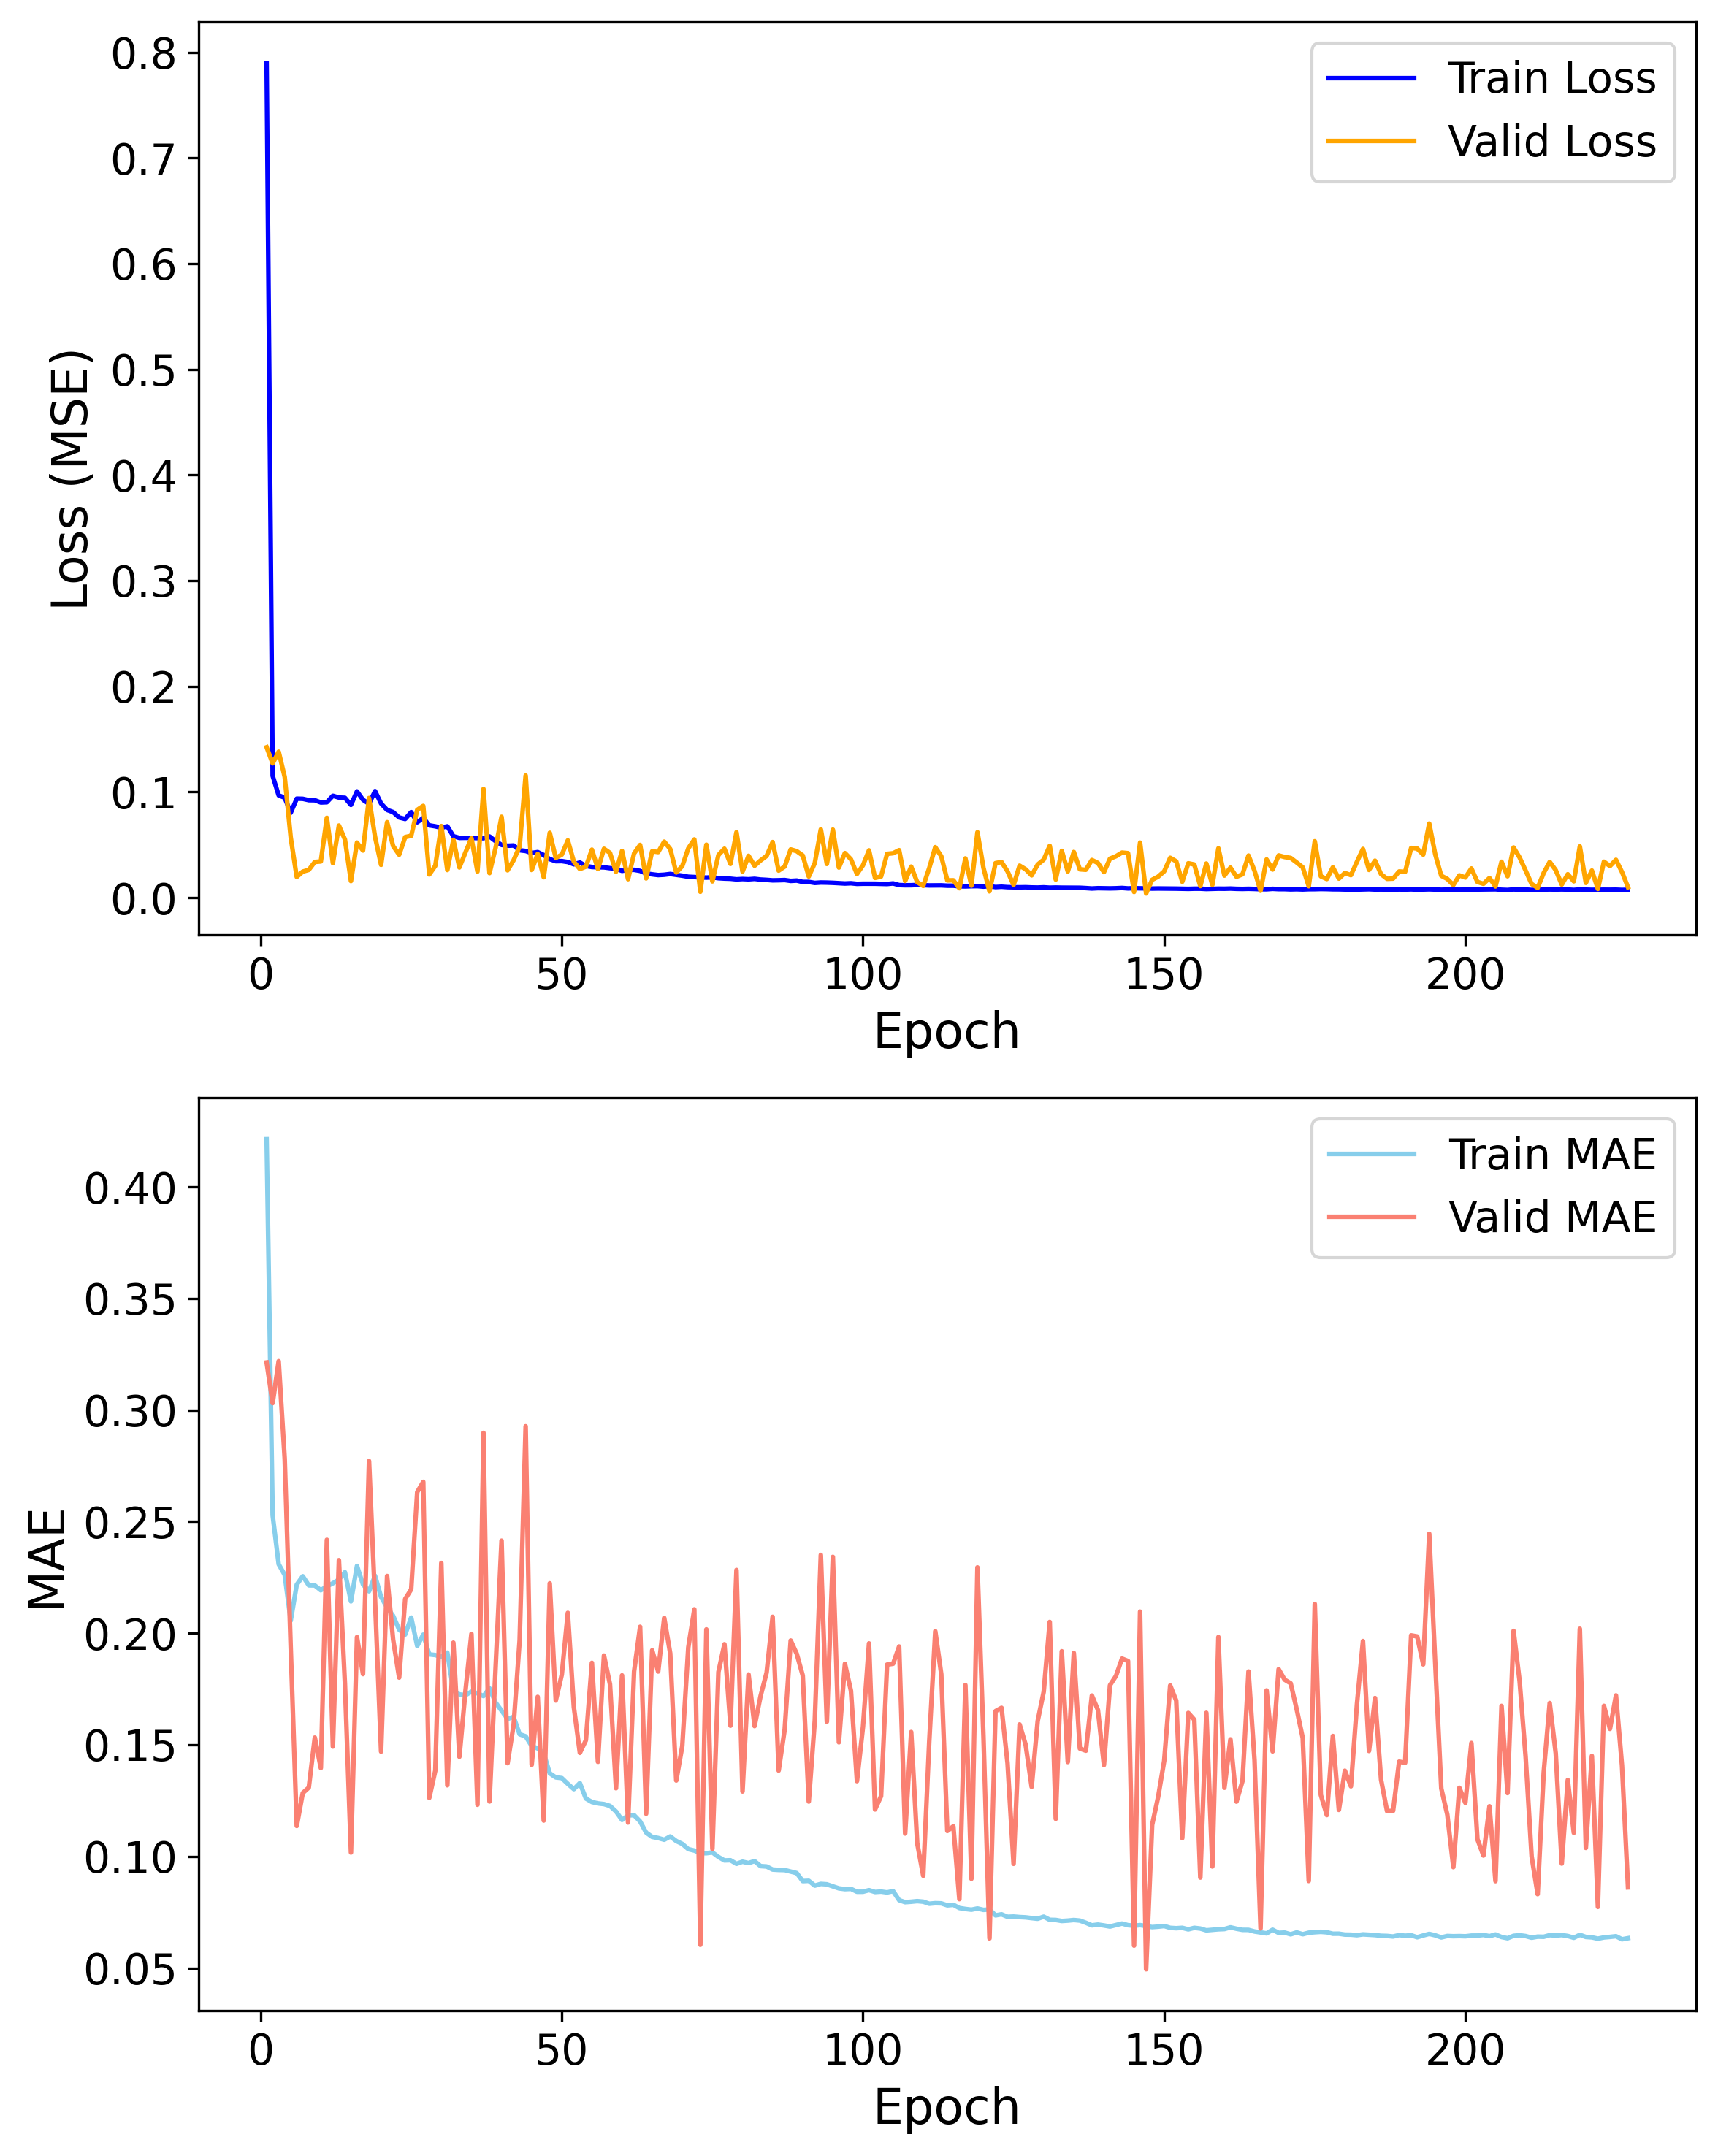

In [22]:
import matplotlib.pyplot as plt
# ------------------- 请修改这里的文件路径 -------------------
csv_path = 'logs/modelB_training_history.csv'  # 如果你改了保存路径，请相应修改这里

# 检查文件是否存在
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"找不到训练历史文件：{csv_path}\n请确认路径正确，或者检查 train_model 是否成功保存了 CSV 文件。")

# 读取数据
df = pd.read_csv(csv_path)

# 显示前几行（可选，方便检查）
print("训练历史前几行：")
print(df.head())

# ------------------- 可视化 -------------------
plt.figure(figsize=(8, 10))

# 子图1：Loss 曲线
plt.subplot(2, 1, 1)
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue')
plt.plot(df['epoch'], df['valid_loss'], label='Valid Loss', color='orange')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss (MSE)', fontsize=16)
plt.legend(fontsize=14)


# 子图2：MAE 曲线
plt.subplot(2, 1, 2)
plt.plot(df['epoch'], df['train_mae'], label='Train MAE', color='skyblue')
plt.plot(df['epoch'], df['valid_mae'], label='Valid MAE', color='salmon')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.legend(fontsize=14)


# 整体美化
plt.tight_layout()
plt.savefig('logs/traininghistory_CaseA.pdf', dpi=300, bbox_inches='tight')
plt.show()

torch.Size([14400, 1, 20, 40])
torch.Size([14400, 1])
训练集: 14400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 1800 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 1800 样本, 数据形状 torch.Size([1, 20, 40])
Test Loss: 0.004471 | Test MAE: 0.0524 | Test R²: 0.9961
测试集样本数: 1800
反归一化完成 → klw 范围: [0.000, 7.000]


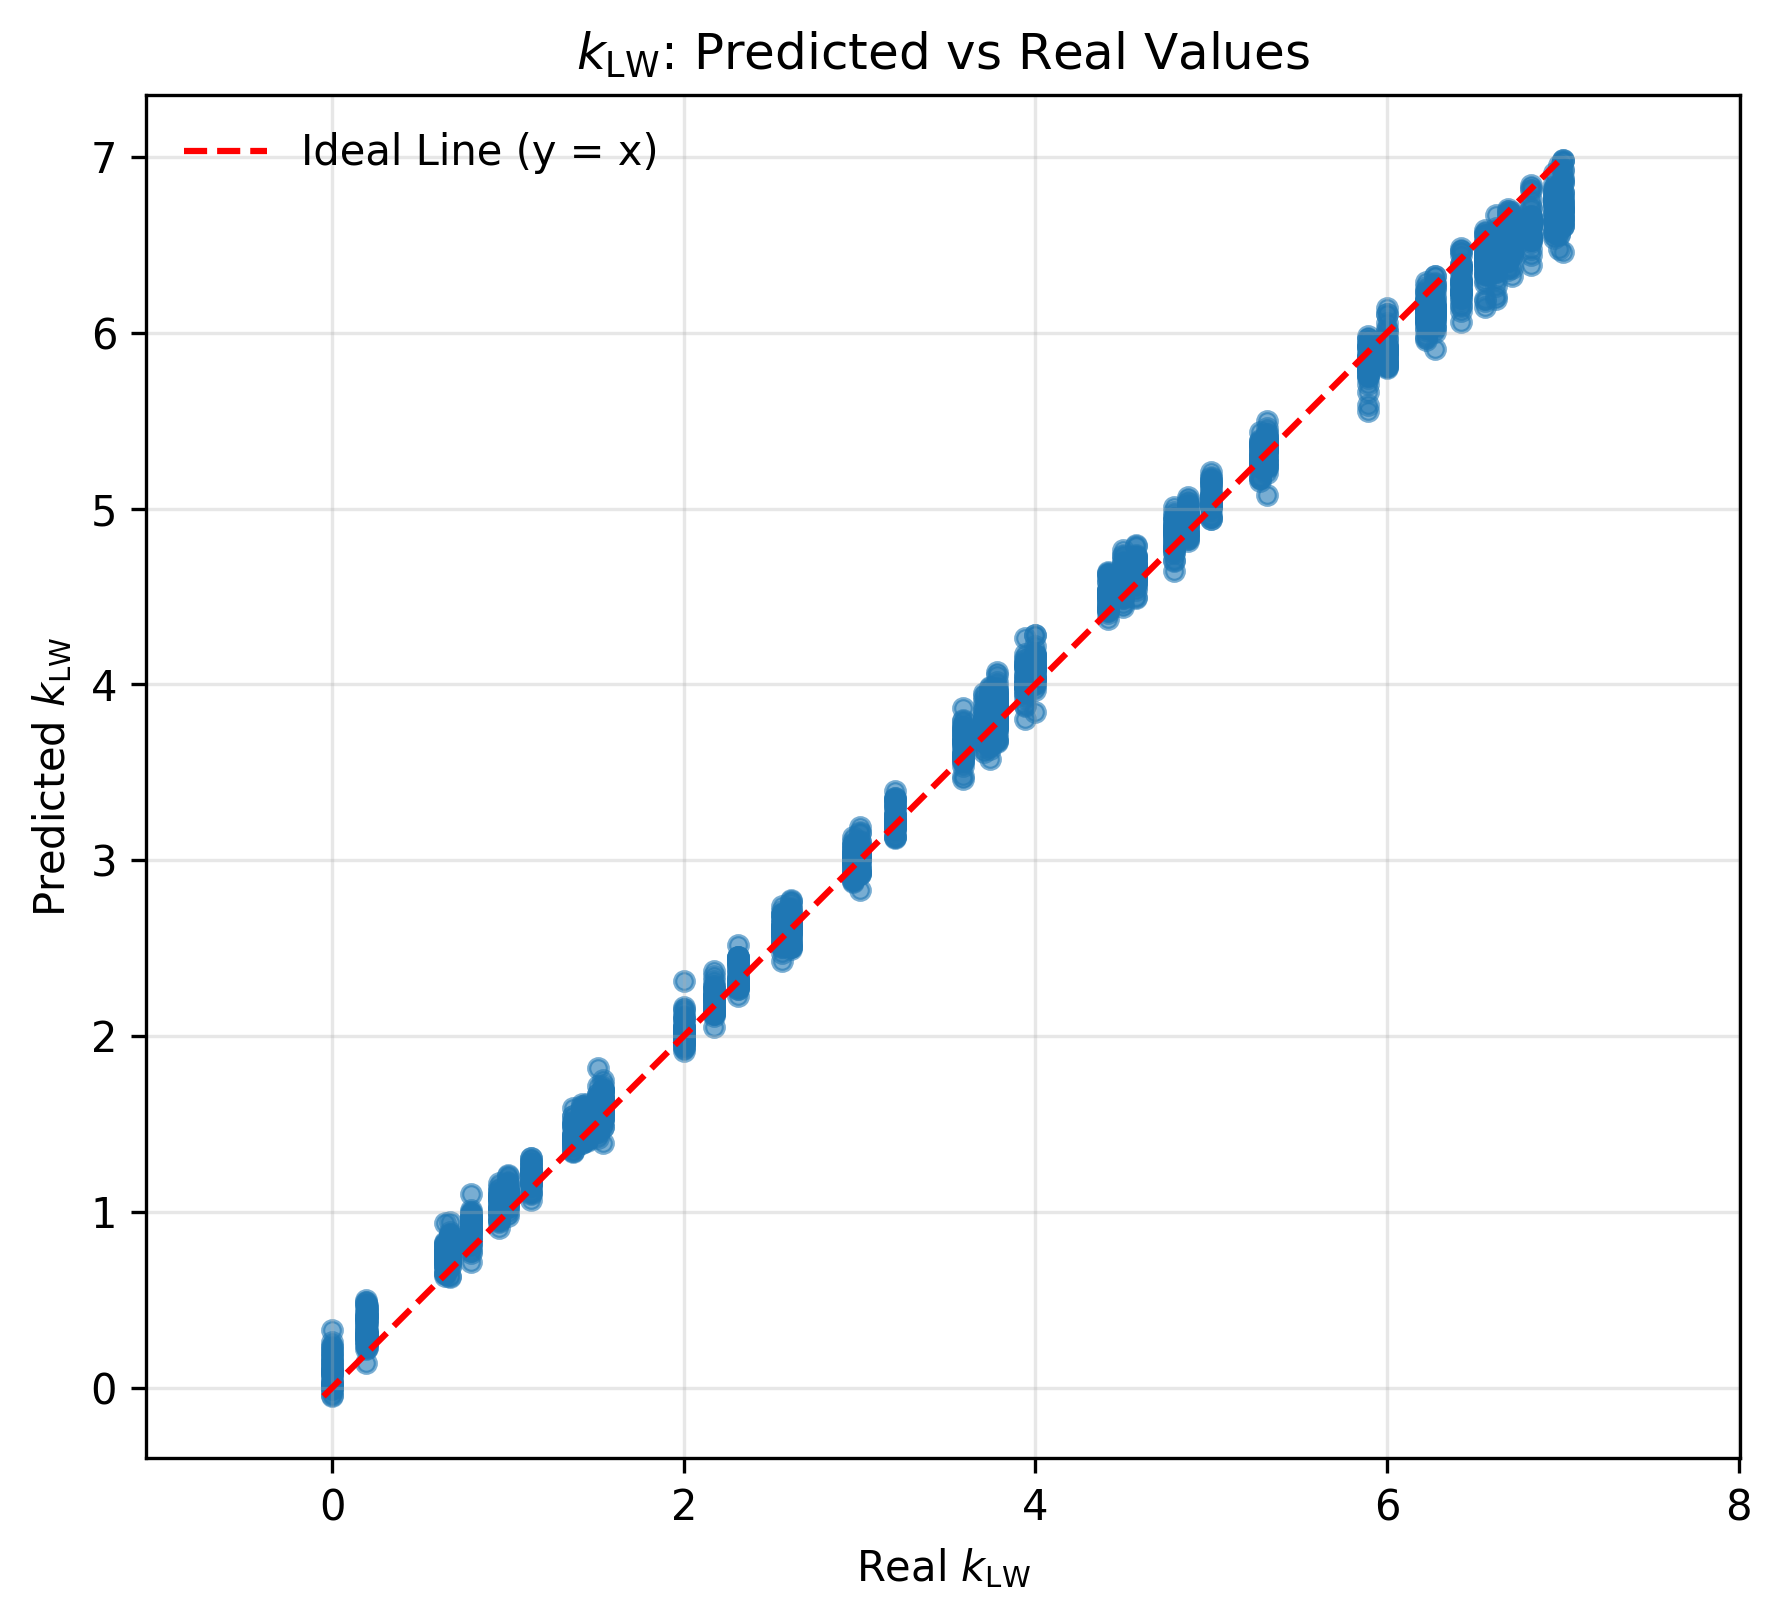

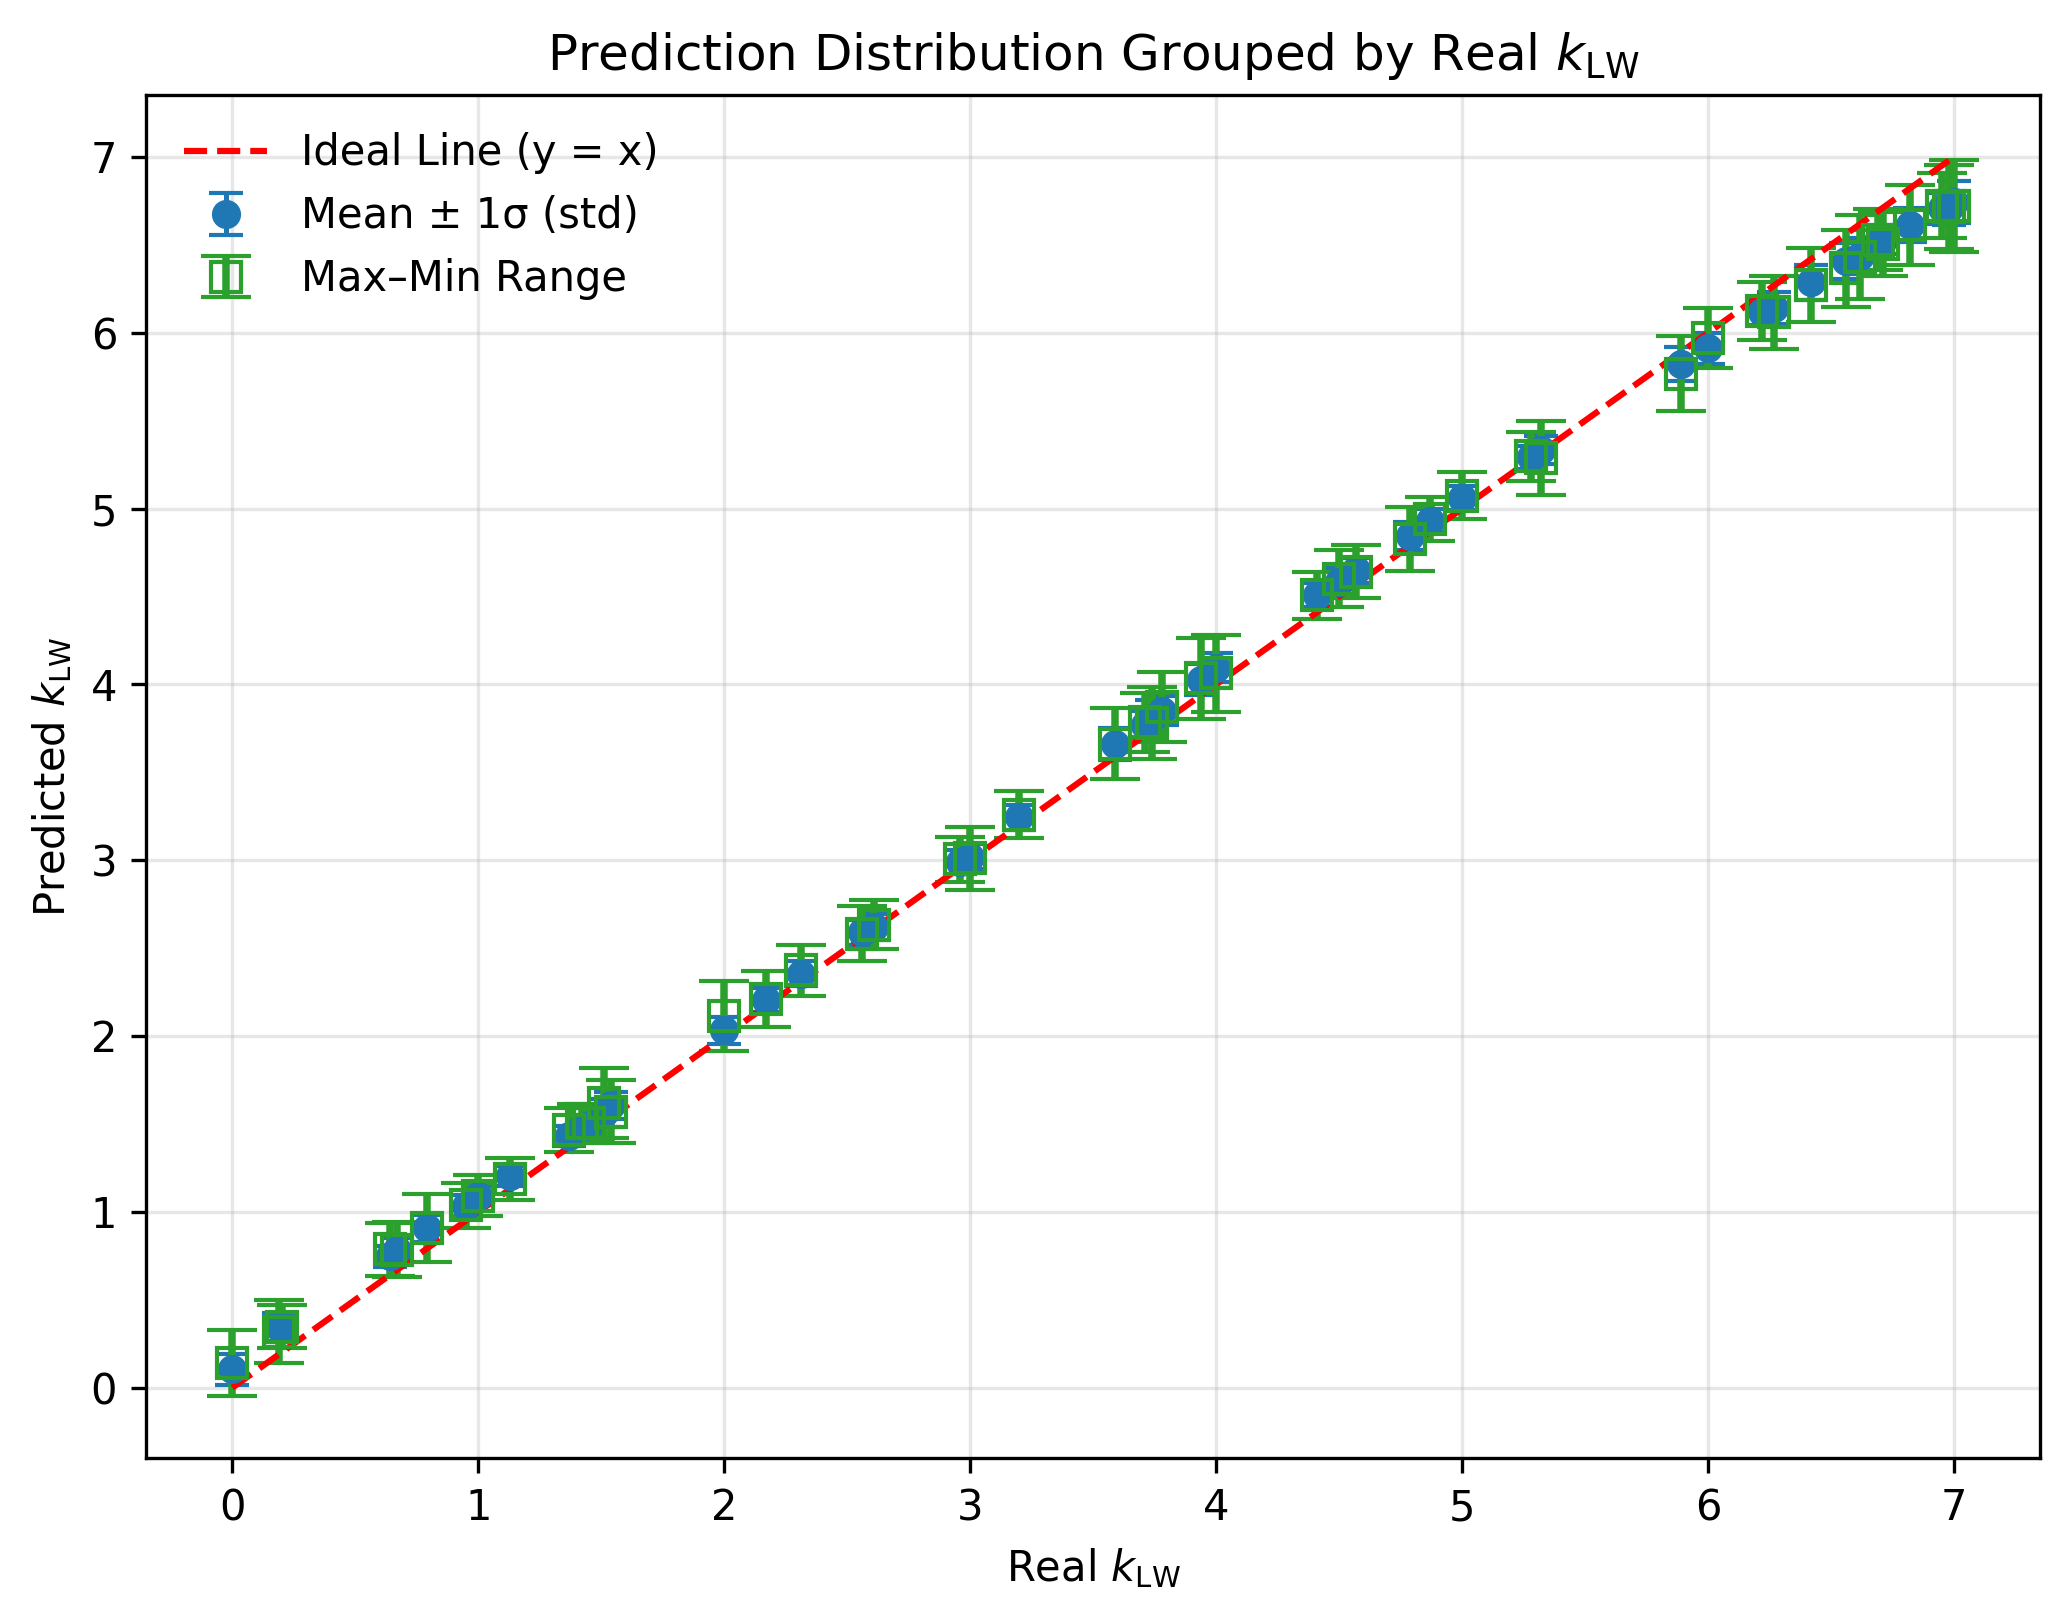


=== k_LW 分组预测统计 ===
Real k_LW	Samples	Mean Pred	±1σ Range		Max-Min Range
----------------------------------------------------------------------
0.000		36		0.1034		[0.0131, 0.1937]		[-0.0495, 0.3288]
0.190		36		0.3444		[0.2629, 0.4259]		[0.1382, 0.4994]
0.200		36		0.3324		[0.2607, 0.4040]		[0.2245, 0.4691]
0.640		36		0.7460		[0.6853, 0.8066]		[0.6366, 0.9353]
0.670		36		0.7811		[0.7121, 0.8500]		[0.6263, 0.9422]
0.790		36		0.9054		[0.8287, 0.9821]		[0.7160, 1.0992]
0.950		36		1.0343		[0.9742, 1.0944]		[0.9059, 1.1665]
1.000		36		1.0925		[1.0397, 1.1453]		[0.9744, 1.2065]
1.130		36		1.2038		[1.1455, 1.2621]		[1.0659, 1.3083]
1.370		36		1.4304		[1.3724, 1.4884]		[1.3418, 1.5903]
1.420		36		1.4843		[1.4208, 1.5478]		[1.3938, 1.6136]
1.450		36		1.4919		[1.4379, 1.5459]		[1.4021, 1.6112]
1.510		36		1.5624		[1.4814, 1.6434]		[1.4206, 1.8206]
1.540		36		1.6065		[1.5292, 1.6838]		[1.3893, 1.7499]
2.000		36		2.0313		[1.9524, 2.1103]		[1.9149, 2.3106]
2.170		36		2.2053		[2.1382, 2.2725]		[2.0493

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==================== 学术论文字体和样式（全局配置） ====================
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['figure.dpi'] = 300  # 高分辨率默认

# ==================== 加载测试数据 ====================
_, _, test_loader = load_data()

# ==================== 初始化模型并加载最佳权重 ====================
model = CNN_SingleParam(dropout_rate=0.3)  # 使用单参数模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model_pre.pt'))  # 注意文件名更新
model.eval()

# ==================== 测试并获取归一化后的预测值 ====================
test_loss, test_mae, test_r2, predictions_norm, trues_norm = test_model(model, test_loader)
# predictions_norm, trues_norm: numpy array, shape (N,)

# ==================== 反归一化到原始 klw 尺度 ====================
label_stats = torch.load('AngularPS/processed_tensors/modelB/label_stats.pt')
mean = label_stats['mean'].item()   # 标量
std = label_stats['std'].item()     # 标量

predictions = predictions_norm * std + mean
trues = trues_norm * std + mean

print(f"测试集样本数: {len(trues)}")
print(f"反归一化完成 → klw 范围: [{trues.min():.3f}, {trues.max():.3f}]")

# ==================== 1. 散点图：预测值 vs 真实值 ====================
plt.figure(figsize=(6, 5.5))

plt.scatter(trues, predictions, alpha=0.6, color='tab:blue', s=20)
min_val = min(trues.min(), predictions.min())
max_val = max(trues.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Ideal Line (y = x)')

plt.xlabel('Real $k_{\\mathrm{LW}}$')
plt.ylabel('Predicted $k_{\\mathrm{LW}}$')
plt.title('$k_{\\mathrm{LW}}$: Predicted vs Real Values')
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.axis('equal')  # 保持坐标轴比例一致，更直观比较偏差

plt.tight_layout()
plt.savefig('klw_prediction_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 2. 误差棒图：按真实 klw 分组显示预测分布 ====================
unique_klw_real = np.unique(trues)
unique_klw_real.sort()

mean_pred = []
std_pred = []
max_pred = []
min_pred = []
sample_counts = []

for klw_real in unique_klw_real:
    mask = np.isclose(trues, klw_real, atol=1e-4)
    group_preds = predictions[mask]
    
    n_samples = len(group_preds)
    sample_counts.append(n_samples)
    
    if n_samples > 1:
        mean_pred.append(np.mean(group_preds))
        std_pred.append(np.std(group_preds))    # 1σ 标准差
        max_pred.append(np.max(group_preds))
        min_pred.append(np.min(group_preds))
    else:
        # 只有一个样本时，无法计算 std，设为 NaN 或 0
        mean_pred.append(group_preds[0])
        std_pred.append(0)
        max_pred.append(group_preds[0])
        min_pred.append(group_preds[0])

mean_pred = np.array(mean_pred)
std_pred = np.array(std_pred)
max_pred = np.array(max_pred)
min_pred = np.array(min_pred)
sample_counts = np.array(sample_counts)

# 绘制误差棒图
plt.figure(figsize=(7, 5.5))

valid_idx = sample_counts > 0  # 所有组都有样本

# 1σ 误差棒（蓝色圆点 + 细误差线）
plt.errorbar(unique_klw_real[valid_idx], mean_pred[valid_idx],
             yerr=std_pred[valid_idx],
             fmt='o', capsize=4, color='tab:blue', elinewidth=1.2, markersize=6,
             label='Mean ± 1σ (std)')

# Max-Min 范围（绿色方框 + 粗误差线）
mid = (max_pred + min_pred) / 2
half_range = (max_pred - min_pred) / 2
plt.errorbar(unique_klw_real[valid_idx], mid[valid_idx],
             yerr=half_range[valid_idx],
             fmt='s', capsize=6, color='tab:green', markerfacecolor='none',
             linewidth=1.8, elinewidth=1.8, markersize=7,
             label='Max–Min Range')

# 理想对角线
plt.plot(unique_klw_real, unique_klw_real, 'r--', lw=1.5, label='Ideal Line (y = x)')

plt.xlabel('Real $k_{\\mathrm{LW}}$')
plt.ylabel('Predicted $k_{\\mathrm{LW}}$')
plt.title('Prediction Distribution Grouped by Real $k_{\\mathrm{LW}}$')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('klw_error_bar_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 3. 打印分组统计信息 ====================
print("\n=== k_LW 分组预测统计 ===")
print("Real k_LW\tSamples\tMean Pred\t±1σ Range\t\tMax-Min Range")
print("-" * 70)
for i, klw_real in enumerate(unique_klw_real):
    if sample_counts[i] == 1:
        print(f"{klw_real:.3f}\t\t{sample_counts[i]}\t\t{mean_pred[i]:.4f}\t\t(single point)\t\t(single point)")
    else:
        lower_1s = mean_pred[i] - std_pred[i]
        upper_1s = mean_pred[i] + std_pred[i]
        print(f"{klw_real:.3f}\t\t{sample_counts[i]}\t\t{mean_pred[i]:.4f}\t\t"
              f"[{lower_1s:.4f}, {upper_1s:.4f}]\t\t[{min_pred[i]:.4f}, {max_pred[i]:.4f}]")

print("\n可视化完成！已保存以下图片：")
print("  - klw_prediction_scatter.png")
print("  - klw_error_bar_distribution.png")

In [30]:
import pandas as pd
import numpy as np

# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

# unique_klw_real 来自之前的代码（已排序的真实 klw 值）
for klw_real in unique_klw_real:
    # 使用容差匹配相同真实值的样本（klw 通常是两位小数，如 0.51）
    mask = np.isclose(trues, klw_real, atol=1e-4)
    group_preds = predictions[mask]  # 该组所有预测的 klw 值（一维数组）
    
    n_samples = len(group_preds)
    if n_samples > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),           # 真实值（保留4位小数便于阅读）
            "sample_count": n_samples,
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds, ddof=1) if n_samples > 1 else 0.0,  # ddof=1 为样本标准差
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "k_LW_pred_median": np.median(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保留所有单个预测值（用于后续分析）
        })

# 创建 DataFrame
df_klw_full = pd.DataFrame(klw_groups)

# === 保存为 CSV ===
csv_filename = "k_LW_group_stats_modelB.csv"
df_klw_full.to_csv(csv_filename, index=False)
print(f"已保存分组统计及所有预测值到：{csv_filename}")
print(f"共 {len(df_klw_full)} 个不同的真实 k_LW 值分组")

# === 预览统计信息（不显示长列表列）===
display_cols = ['k_LW_real', 'sample_count', 'k_LW_pred_mean', 
                'k_LW_pred_std', 'k_LW_pred_median', 
                'k_LW_pred_min', 'k_LW_pred_max']

print("\n分组统计预览：")
print(df_klw_full[display_cols].round(5).to_string(index=False))

已保存分组统计及所有预测值到：k_LW_group_stats_modelB.csv
共 49 个不同的真实 k_LW 值分组

分组统计预览：
 k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_median  k_LW_pred_min  k_LW_pred_max
      0.00            36         0.10342        0.09159           0.09535       -0.04951        0.32875
      0.19            36         0.34439        0.08265           0.33167        0.13820        0.49943
      0.20            36         0.33236        0.07270           0.30566        0.22448        0.46912
      0.64            36         0.74597        0.06154           0.74733        0.63660        0.93533
      0.67            36         0.78105        0.06991           0.77977        0.62630        0.94223
      0.79            36         0.90542        0.07778           0.90372        0.71604        1.09921
      0.95            36         1.03429        0.06094           1.02220        0.90586        1.16654
      1.00            36         1.09253        0.05355           1.09568        0.97445       

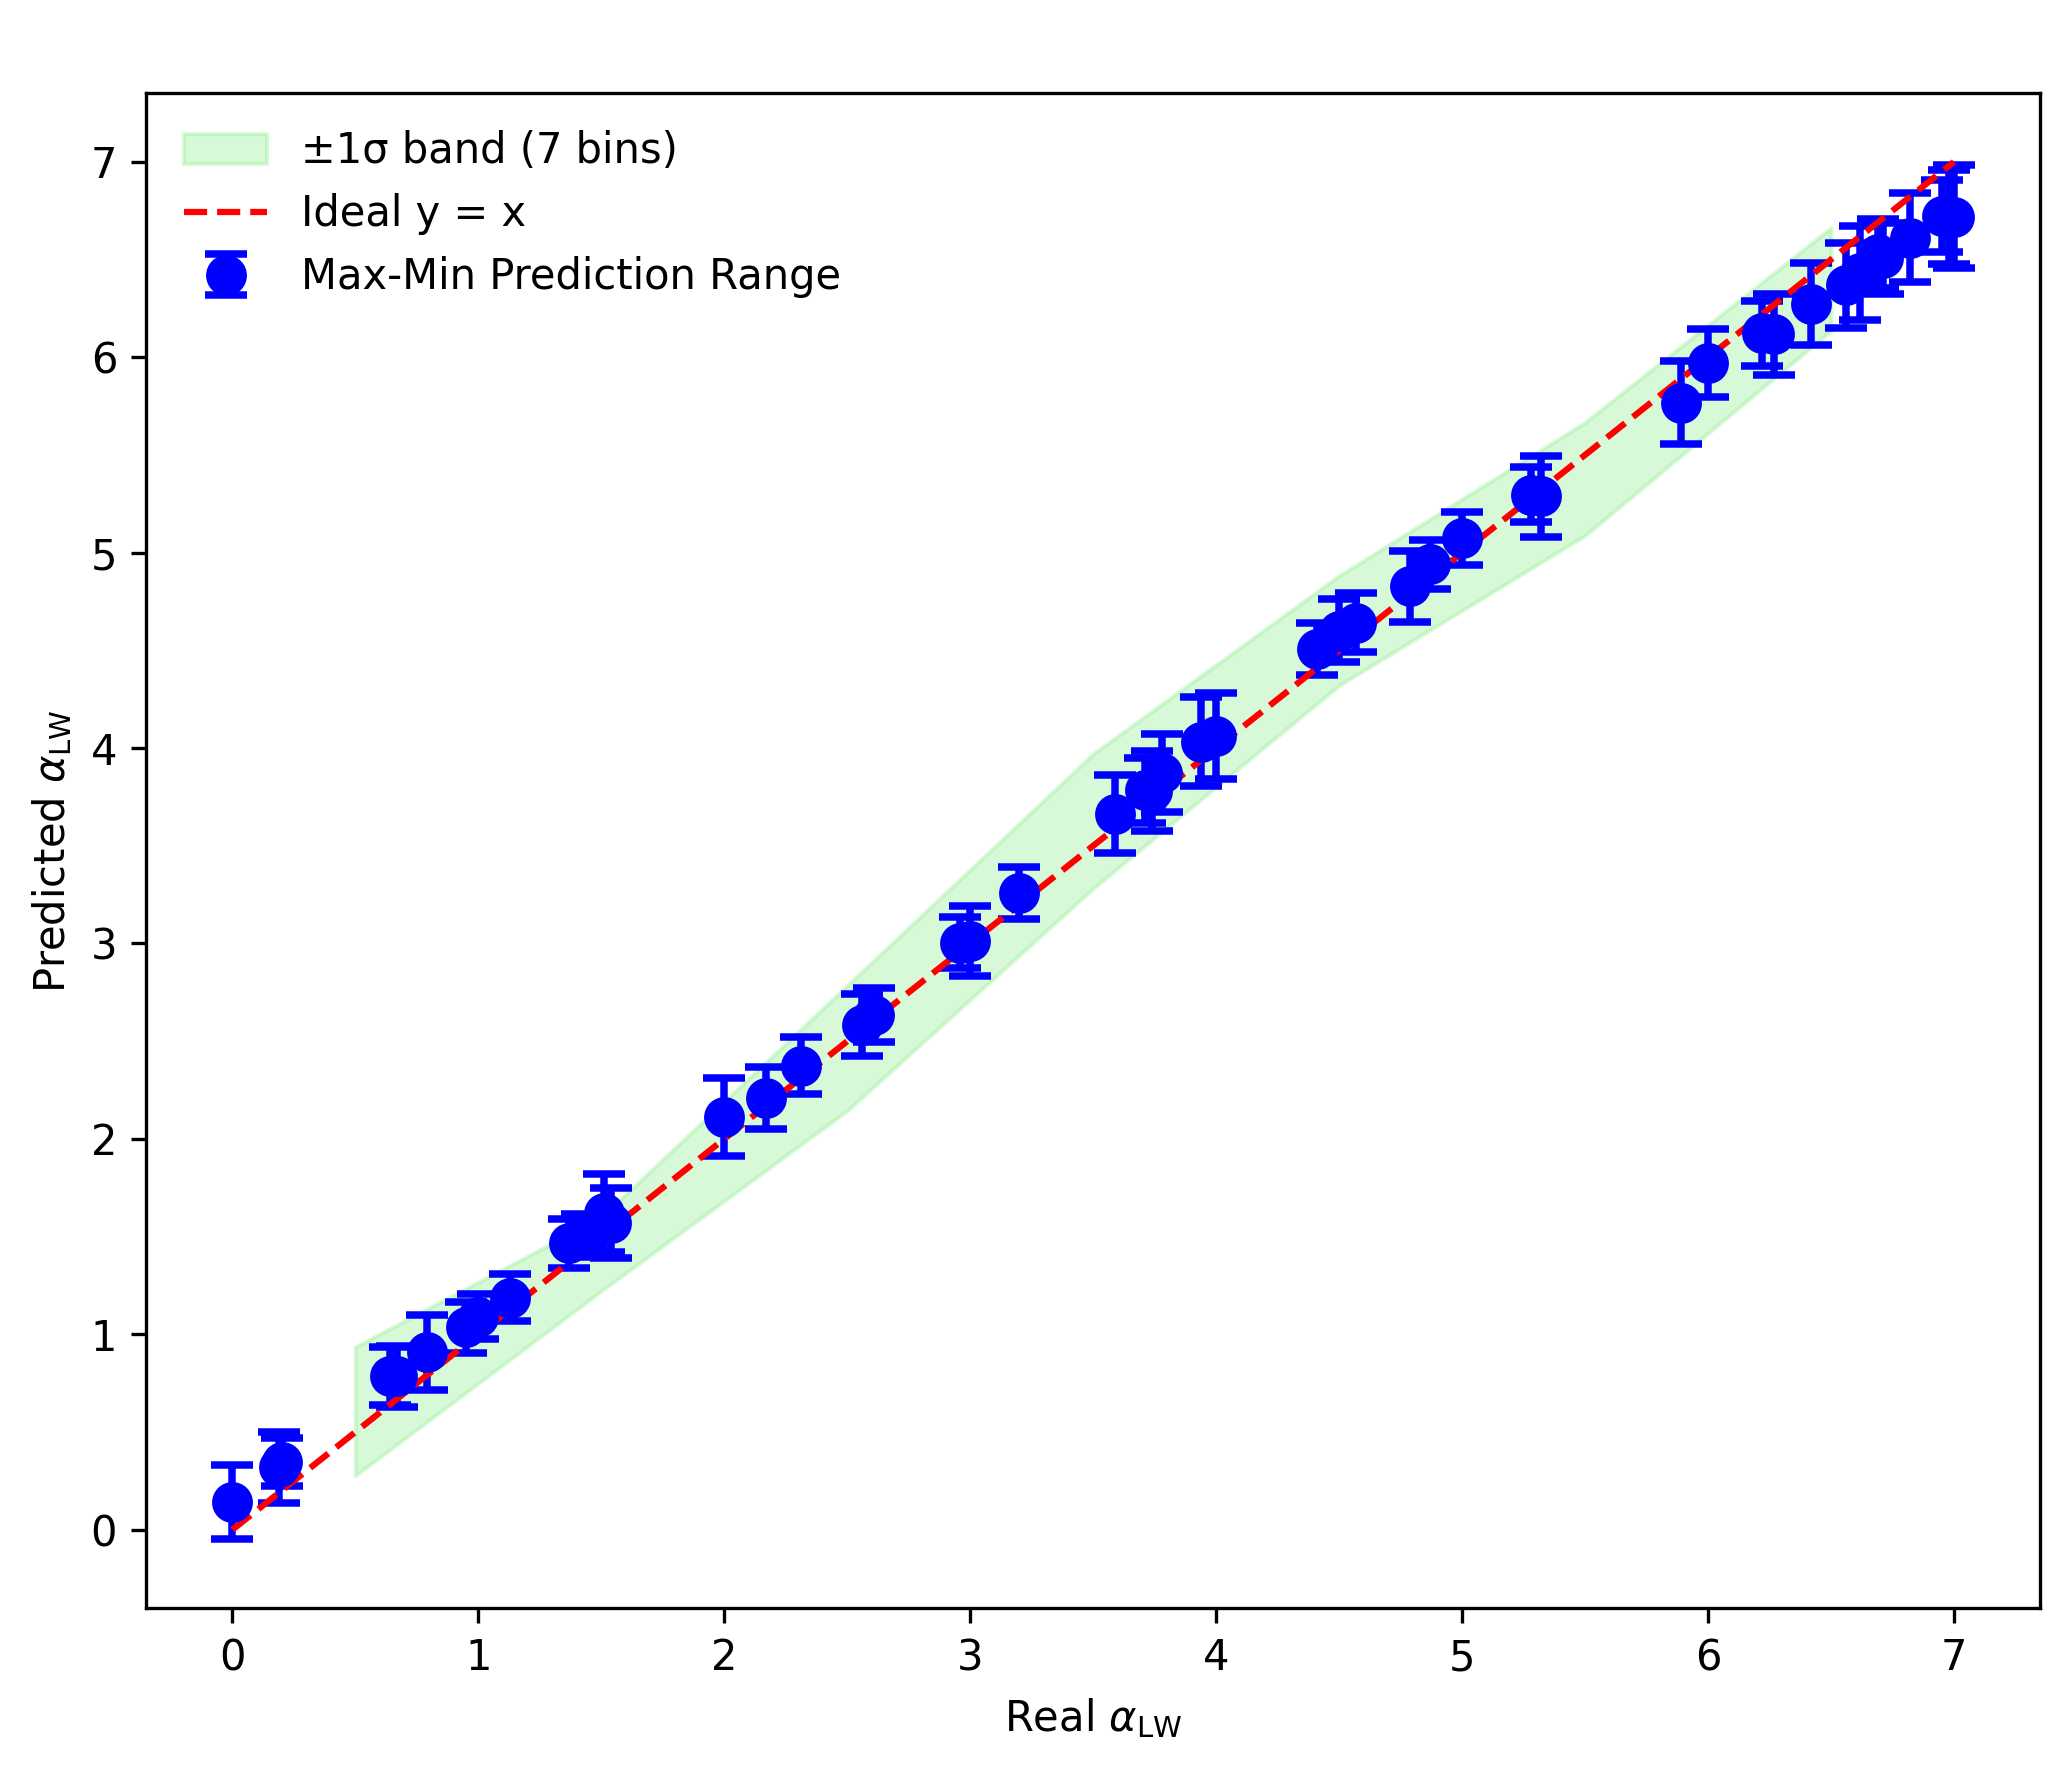

In [ ]:
# ====================== 新代码块：四张独立图（Max-Min errorbar 实心中心 + 7bin 1σ色带） ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k_nonoise   = pd.read_csv("k_LW_group_stats_modelB.csv")    # 无噪音

# --------------------- 函数：绘制单张独立图（Max-Min errorbar 实心中心） ---------------------
def plot_maxmin_with_sigma_band(df, real_col, min_col, max_col, mean_col, std_col,
                                title, xlabel, ylabel, filename, use_sci=False, nbins=7):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    pred_mean = df_valid[mean_col].values if mean_col in df_valid else (pred_min + pred_max)/2
    pred_std = df_valid[std_col].values if std_col in df_valid else np.zeros_like(pred_min)
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === 7个均匀bin的平滑 ±1σ 色带 ===
    overall_min = real.min()
    overall_max = real.max()
    bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    lowers = np.full(nbins, np.nan)
    uppers = np.full(nbins, np.nan)
    
    for i in range(nbins):
        mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
        if np.sum(mask) > 1:
            bin_means = pred_mean[mask]
            bin_stds = pred_std[mask]
            combined_mean = np.mean(bin_means)
            combined_std = np.sqrt(np.mean(bin_stds**2) + np.var(bin_means))
            lowers[i] = combined_mean - combined_std
            uppers[i] = combined_mean + combined_std
    
    ax.fill_between(bin_centers, lowers, uppers, color='lightgreen', alpha=0.35, label='±1σ band (7 bins)')
    
    # === Max-Min Prediction Range errorbar（中心实心圆点）===
    mid = (pred_min + pred_max) / 2
    err = (pred_max - pred_min) / 2
    ax.errorbar(real, mid, yerr=err,
                fmt='o', color='blue', capsize=5, markersize=8,
                markerfacecolor='blue', markeredgewidth=1.8, elinewidth=1.8,  # 实心中心 + 粗边/棒
                label='Max-Min Prediction Range')
    
    # 理想线
    ax.plot([overall_min, overall_max], [overall_min, overall_max], 'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# k_LW 无噪音
plot_maxmin_with_sigma_band(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title=" ",
    xlabel="Real $\\alpha_{\\mathrm{LW}}$",
    ylabel="Predicted $\\alpha_{\\mathrm{LW}}$",
    filename="kLW_maxmin_filled_modelB.pdf"
)



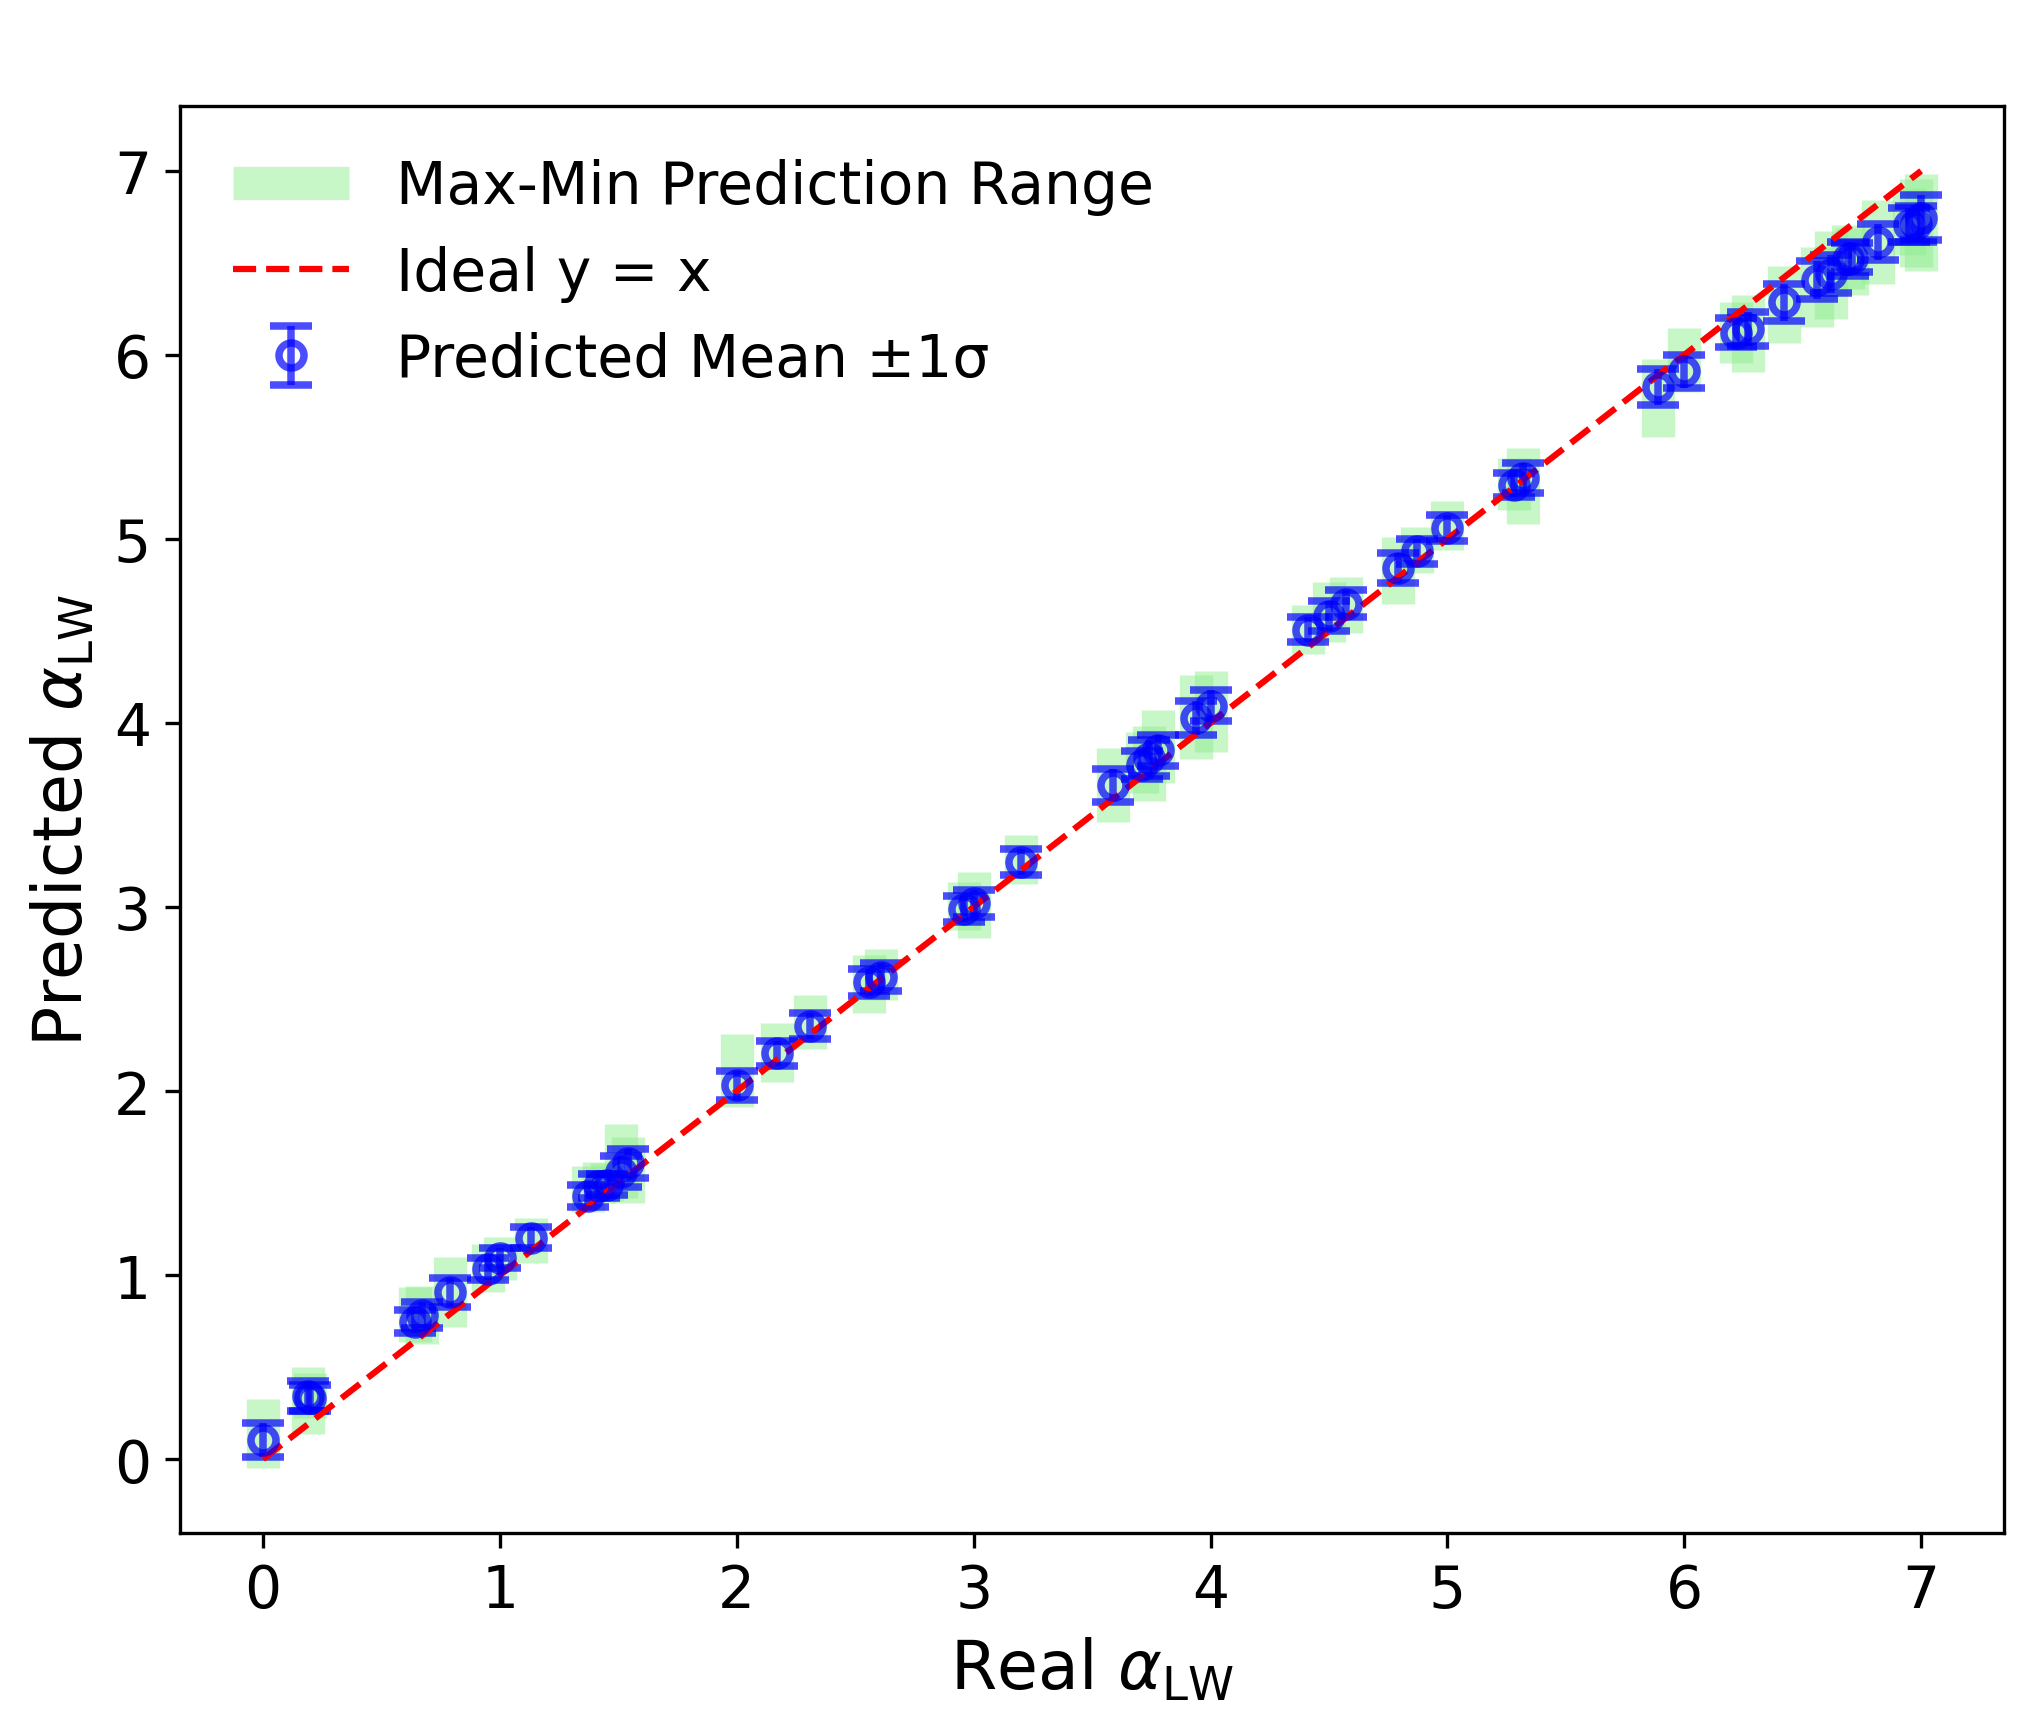

In [25]:
# ====================== 修改版：无bin色带（Max-Min范围填充） + errorbar显示±1σ ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据
df_k_nonoise = pd.read_csv("k_LW_group_stats_modelB.csv")    # 无噪音

# --------------------- 修改后的绘制函数 ---------------------
def plot_maxmin_band_with_sigma_errorbar(df, real_col, min_col, max_col, mean_col, std_col,
                                         title, xlabel, ylabel, filename, use_sci=False):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    
    # 预测均值（若无则取中点）
    if mean_col in df_valid.columns and not df_valid[mean_col].isna().all():
        pred_mean = df_valid[mean_col].values
    else:
        pred_mean = (pred_min + pred_max) / 2
    
    # 预测标准差（若无则为0）
    if std_col in df_valid.columns and not df_valid[std_col].isna().all():
        pred_std = df_valid[std_col].values
    else:
        pred_std = np.zeros_like(pred_min)
    
    # 为了填充Max-Min范围，需要对点按real值排序
    sort_idx = np.argsort(real)
    real_sorted = real[sort_idx]
    min_sorted = pred_min[sort_idx]
    max_sorted = pred_max[sort_idx]
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === Max-Min 预测范围色带（不分bin，直接填充所有点的min到max）===
    ax.vlines(real_sorted, min_sorted, max_sorted,
                    color='lightgreen', alpha=0.5,linewidth=8,
                    label='Max-Min Prediction Range')
    
    # === errorbar 显示 ±1σ（中心为均值，实心圆点）===
    ax.errorbar(real, pred_mean, yerr=pred_std,
                fmt='o', color='blue', capsize=5, markersize=6,
                markerfacecolor='none', markeredgewidth=1.8, elinewidth=1.8, alpha=0.7,
                label='Predicted Mean ±1σ')
    
    # 理想线 y = x
    overall_min = real.min()
    overall_max = real.max()
    ax.plot([overall_min, overall_max], [overall_min, overall_max],
            'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.legend(frameon=False, fontsize=14)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --------------------- 绘制无噪音图 ---------------------
plot_maxmin_band_with_sigma_errorbar(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title=" ",
    xlabel="Real $\\alpha_{\\mathrm{LW}}$",
    ylabel="Predicted $\\alpha_{\\mathrm{LW}}$",
    filename="alphaLW_CaseA.pdf"
)

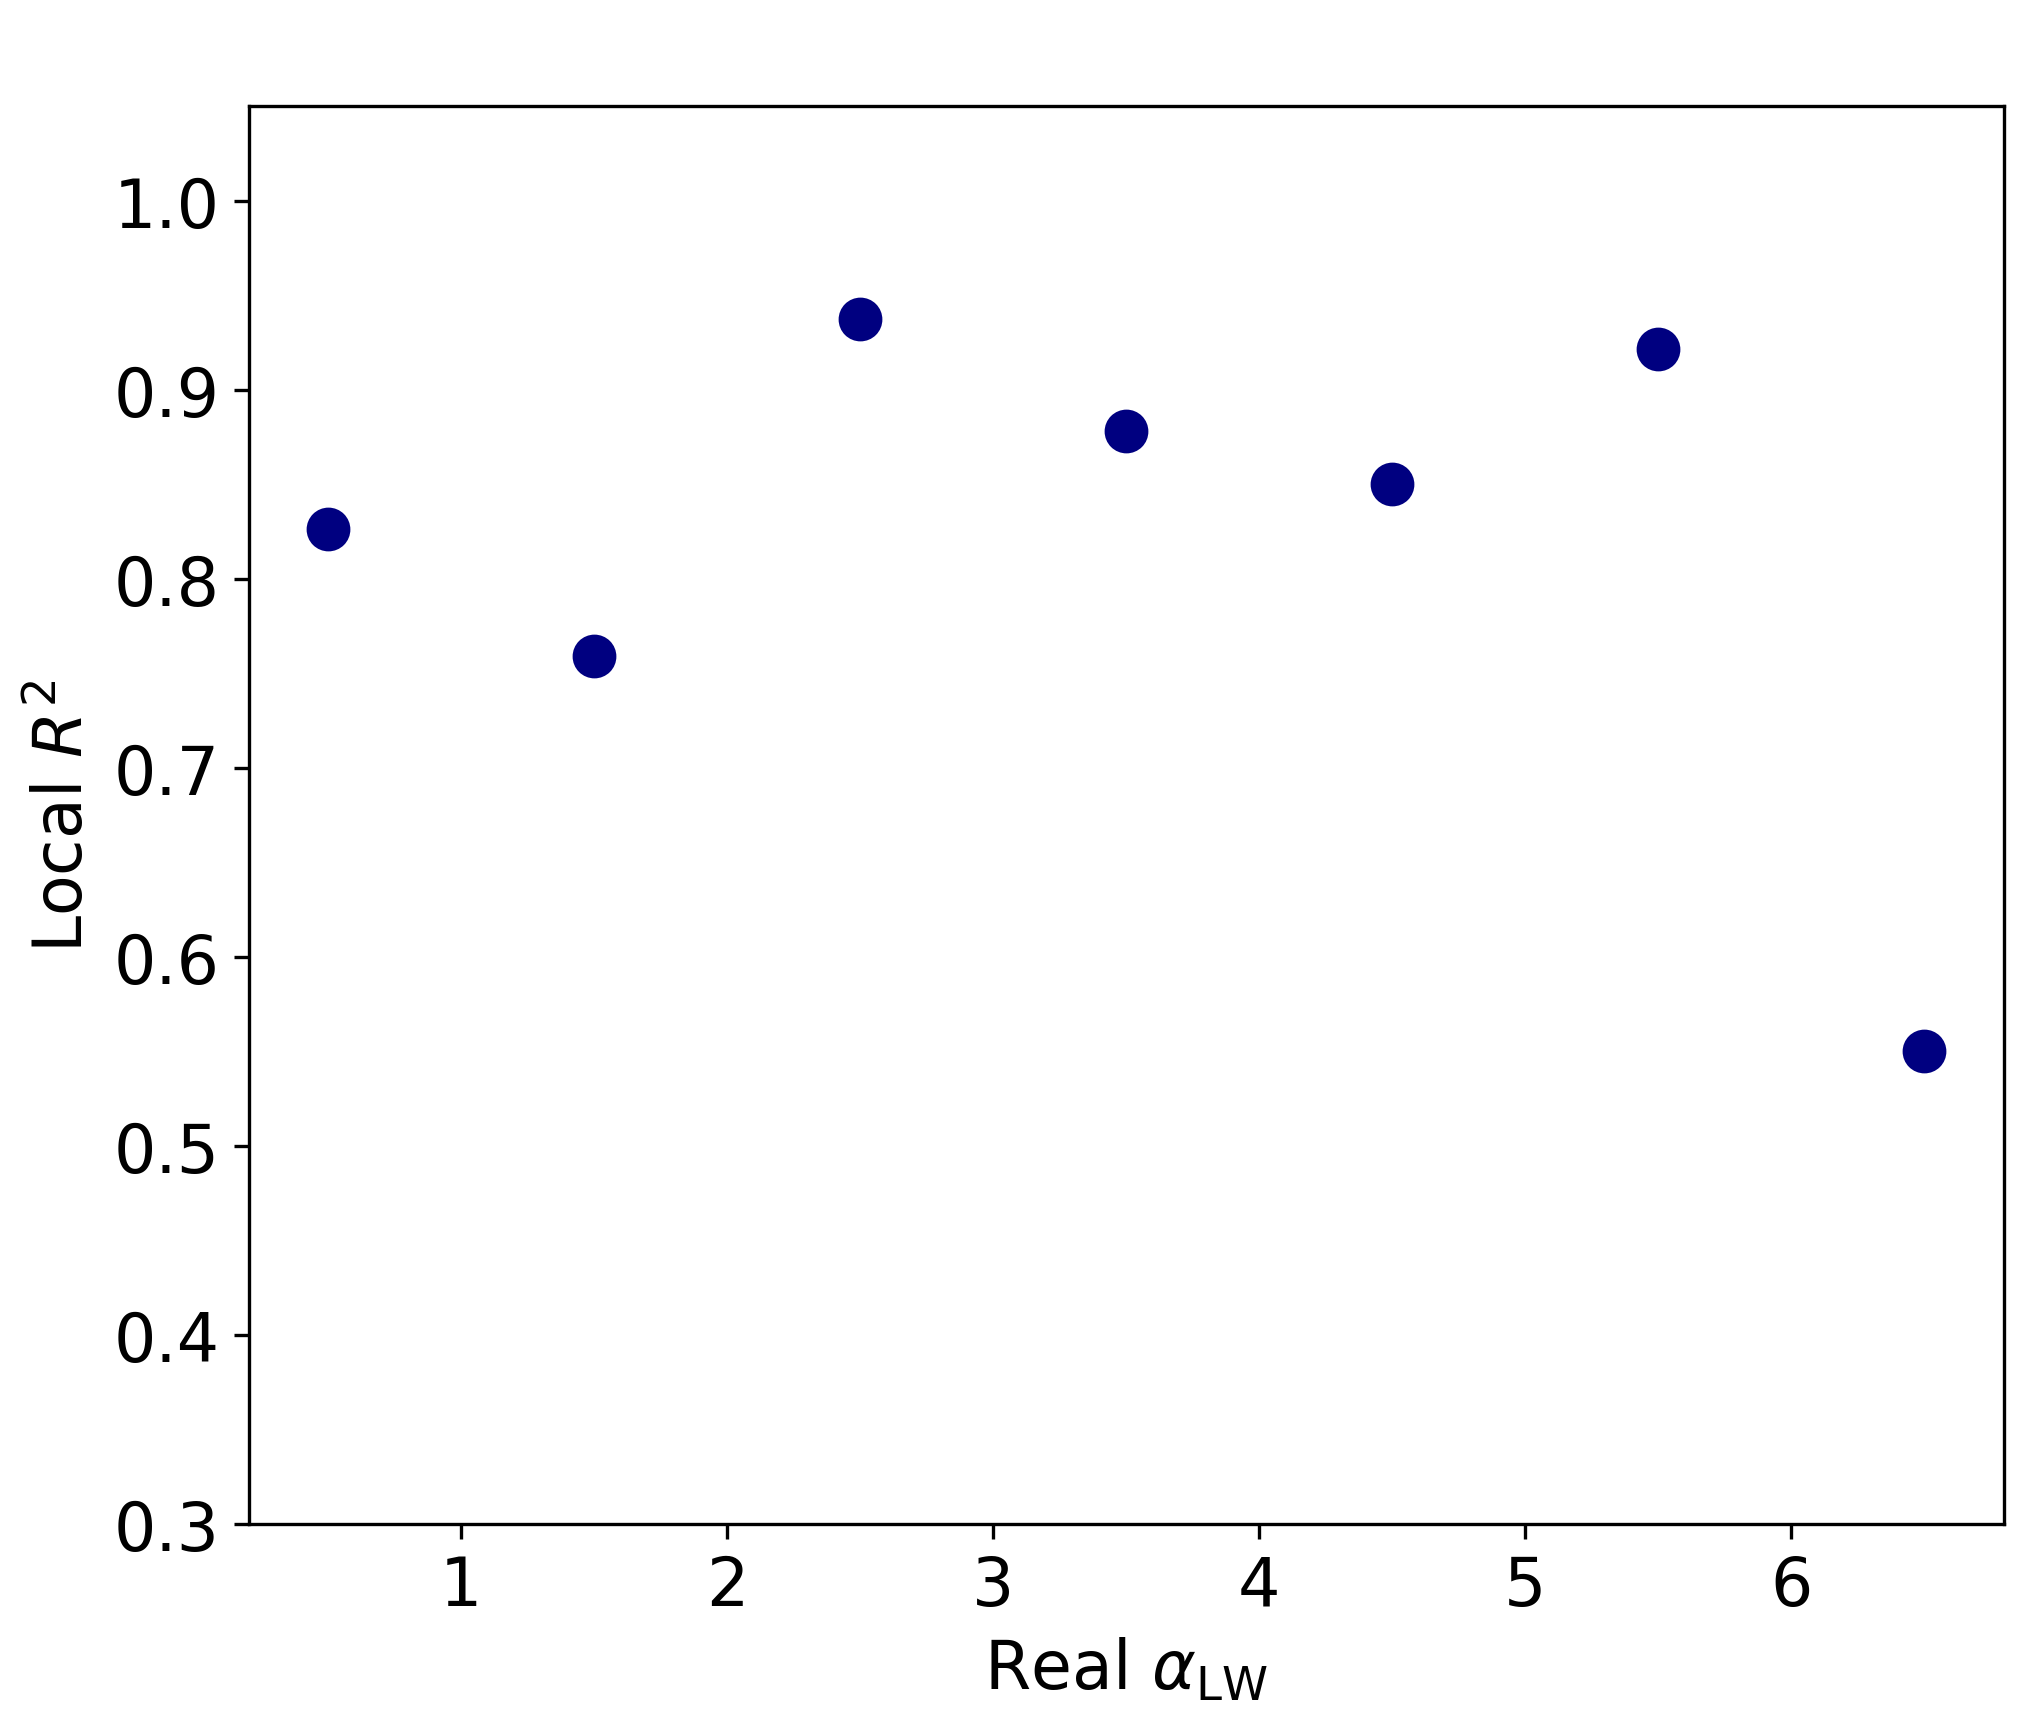

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格（与你原代码一致）
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['text.usetex'] = False

predictions = predictions_norm * std + mean
trues = trues_norm * std + mean

real = trues
pred = predictions

# --------------------- 计算分 bin 的局部 R² ---------------------
nbins = 7  # 可调整 bin 数量

overall_min = real.min()
overall_max = real.max()
bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

r2_per_bin = np.full(nbins, np.nan)

for i in range(nbins):
    mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
    if np.sum(mask) >= 2:  # 至少 2 个样本才能计算 R²
        y_true_bin = real[mask]
        y_pred_bin = pred[mask]
        
        ss_res = np.sum((y_true_bin - y_pred_bin) ** 2)
        ss_tot = np.sum((y_true_bin - np.mean(y_true_bin)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        r2_per_bin[i] = r2
    else:
        r2_per_bin[i] = np.nan

# --------------------- 绘图 ---------------------
fig, ax = plt.subplots(figsize=(7, 6))

# 实心圆点标记每个 bin 的 R² 值
ax.plot(bin_centers, r2_per_bin, 'o', color='navy', markerfacecolor='navy',
        markersize=9, markeredgewidth=1.5, label='Local $R²$')

ax.set_xlabel("Real $\\alpha_{\\mathrm{LW}}$", fontsize=16)
ax.set_ylabel("Local $R^2$", fontsize=16)
ax.set_title(" ")  # 论文插图通常留空，由 caption 说明
ax.set_ylim(0.3, 1.05)  # 留出空间显示负值（如果有）

plt.tight_layout()
plt.savefig("local_R2_caseA.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("local_R2_vs_real_modelB.png", dpi=300, bbox_inches='tight')
plt.show()